Netflix is known for its work in data science, AI, and ML particularly for building strong recommendation models and algorithms that understand customer behavior and patterns. suppose you are working in a data driven job role, and you have a dataset of more than 9000 movies. you need to solve that following questions to help that company make informed business decisions accordingly.

1)- What is the most frequent genre of the movies released on Netflix?

Answer- Drama is the highest Genre that get frequency of 3744.

2)- What genres has highest vote avg column?

Answer- History get 6.9 vote_average.History is the highest Genre that get highest vote avg.

3)- What movie got the highest popularity? What's its genre?

Answer- Spiderman- No way home is the highest popular movie which get 5083.954 popularity.

4)- What movie got the lowest Popularity? What's its genre?

Answer-The United States vs. Billie Holiday is the lowest popular movie which get  13.354 popularity.

5)- Which year has the most filmmed movies?

Answer- In year -2021 has most movie is filmed-713.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv(
    r'C:\Users\danis\Downloads\mymoviedb.csv',
    engine='python',
    on_bad_lines='skip'
)

In [47]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [5]:
df.shape

(9837, 9)

In [6]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


)==Exploration Summary
- We have a data frame consosting of 9837 rows and 9 columns.
- Our dataset looks a bit tidy with 10 Nan and the nan value are the duplicate value so we need to remove the value
- Release_date column needs to be casted into date time and to excract only the year value and the Vote_count and Vote_Average is in string so we need to convert it into numeric value
- Need to remove Overview,Original_language, and poster-url these are not use in the analysis and Our busness problem didnot need it
- Ther are noticable outliers in popularity column
- Vote_Average better be categorised for proper analysis
- Genre column has comma saperated value and white spaces that eed to be handle and casted
-

In [48]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [49]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')


In [50]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

In [51]:
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[us]
 1   Title              9828 non-null   str           
 2   Overview           9828 non-null   str           
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9826 non-null   float64       
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9827 non-null   str           
 7   Genre              9826 non-null   str           
 8   Poster_Url         9826 non-null   str           
dtypes: datetime64[us](1), float64(3), str(5)
memory usage: 691.8 KB


In [13]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9827,9827.000000,9826.000000,9826.000000
mean,2006-09-23 11:05:51.317798,40.320570,1392.943721,6.439467
min,1902-04-17 00:00:00,7.100000,0.000000,0.000000
25%,2000-10-18 00:00:00,16.127500,146.000000,5.900000
50%,2011-09-13 00:00:00,21.191000,444.000000,6.500000
75%,2017-11-22 00:00:00,35.174500,1376.000000,7.100000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000
std,NaN,108.874308,2611.303856,1.129797


In [52]:
df.isnull().sum()

Release_Date         10
Title                 9
Overview              9
Popularity           10
Vote_Count           11
Vote_Average         11
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(8)

In [54]:
df[df.duplicated(keep=False)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1106,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1107,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1108,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1109,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1111,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1112,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1113,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1114,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
df = df.dropna()

In [56]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [57]:
qtr1 = df['Vote_Count'].quantile(0.25)
qtr2 = df['Vote_Count'].quantile(0.50)
qtr3 = df['Vote_Count'].quantile(0.75)

In [58]:
IQR = qtr3-qtr1

In [59]:
upper_limit = qtr3+(1.5*IQR)
Lower_limit = qtr1-(1.5*IQR)
print(Lower_limit, upper_limit)

-1699.0 3221.0


In [60]:
df[(df["Vote_Count"]>=upper_limit) & (df["Vote_Count"] <= Lower_limit)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url


In [61]:
df= df.drop(columns=['Overview','Original_Language','Poster_Url'])

In [62]:
df['Release_Date'] = df['Release_Date'].dt.year

**Categorizing Vote_Average Column**

We would cur the vote_Average values and make 4 categories popular average below_avg not_popular provided above


In [25]:
# Define your boundary bins and matching labels
bins = [0, 3.5, 6.0, 8.5, 10.0]
labels = ['Not Popular', 'Below_Average', 'Popular', 'Very Popular']

df['Vote_Average'] = pd.cut(df['Vote_Average'], bins=bins, labels=labels, include_lowest=True)


In [26]:
def cato(vote):
    if vote >= 8.5:
        return "Very Popular"
    elif vote >= 6.0 and vote < 8.5:
        return "Popular"
    elif vote >= 3.5 and vote < 6.0:
        return "Below_Average"
    else:
        return "Not Popular"

df['Vote_Average'] = df['Vote_Average'].apply(cato)


TypeError: '>=' not supported between instances of 'str' and 'float'

In [ ]:
''''/*def catigories_col(df,col,lebels):
    edge = [df[col].describr()['min'],
            df[col].describr()['25%'],
            df[col].describr()['50%'],
            df[col].describr()['75%'],
            df[col].describr()['max']]
    df[col]= pd.cut(df[col], lebels, labels=edge, include_lowest=True)*/'''

In [63]:
df

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,6.3,Thriller
3,2021,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9832,1973,Badlands,13.357,896.0,7.6,"Drama, Crime"
9833,2020,Violent Delights,13.356,8.0,3.5,Horror
9834,2016,The Offering,13.355,94.0,5.0,"Mystery, Thriller, Horror"
9835,2021,The United States vs. Billie Holiday,13.354,152.0,6.7,"Music, Drama, History"


In [64]:
df["Vote_Average"].value_counts()

Vote_Average
6.4     435
6.3     429
6.5     427
6.8     423
6.7     420
       ... 
9.2       1
1.8       1
2.4       1
2.6       1
10.0      1
Name: count, Length: 74, dtype: int64

**We'd split genres into a list and then explode our dataframe to have only one genre per row for each movie**

In [65]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)

In [31]:
df

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,Popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,Popular,Crime
4,2022,The Batman,3827.658,1151.0,Popular,Mystery
...,...,...,...,...,...,...
25787,2021,The United States vs. Billie Holiday,13.354,152.0,Popular,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152.0,Popular,History
25789,1984,Threads,13.354,186.0,Popular,War
25790,1984,Threads,13.354,186.0,Popular,Drama


In [66]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [67]:
df.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average      74
Genre             19
dtype: int64

In [68]:
df

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,Science Fiction
3,2022,The Batman,3827.658,1151.0,8.1,Crime
4,2022,The Batman,3827.658,1151.0,8.1,Mystery
...,...,...,...,...,...,...
25787,2021,The United States vs. Billie Holiday,13.354,152.0,6.7,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152.0,6.7,History
25789,1984,Threads,13.354,186.0,7.8,War
25790,1984,Threads,13.354,186.0,7.8,Drama


In [69]:
count=df.groupby(['Release_Date','Genre']).size()
count.groupby(level='Release_Date').idxmax()

Release_Date
1902    (1902, Adventure)
1920        (1920, Crime)
1921        (1921, Drama)
1922       (1922, Horror)
1925        (1925, Drama)
              ...        
2020        (2020, Drama)
2021        (2021, Drama)
2022        (2022, Drama)
2023    (2023, Adventure)
2024    (2024, Adventure)
Length: 102, dtype: object

***1)- What is the most frequent genre of the movies released on Netflix?***

For this we have use catplot to get the most frequency genre


In [70]:
sns.set_style('whitegrid')

In [71]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

In [72]:
df['Genre'].value_counts()

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

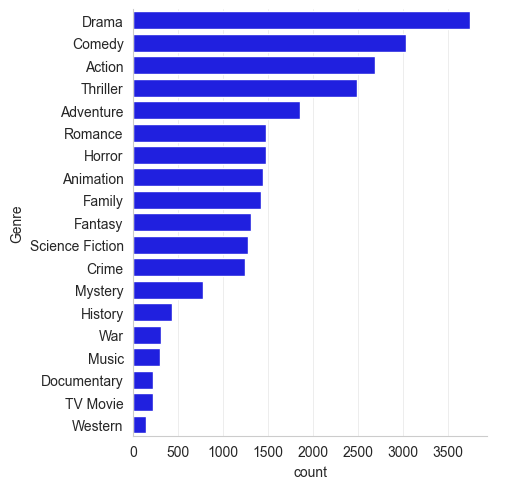

In [73]:
sns.catplot(y='Genre',data = df,kind="count",order=df['Genre'].value_counts().index,color='blue')
plt.show()

***2)- What genres has highest vote avg column?***

To Get this we use catplot to see which

In [82]:
df.groupby('Genre')['Vote_Average'].mean().idxmax()

'History'

In [43]:
maxgen = df.groupby(['Genre'])['Vote_Average'].idxmax()
df.loc[maxgen,["Vote_Average","Release_Date","Genre"]]


,Vote_Average,Release_Date,Genre
1917,Very Popular,2019,Action
13448,Very Popular,2021,Adventure
121,Very Popular,2022,Animation
123,Very Popular,2022,Comedy
1741,Very Popular,1972,Crime
6633,Very Popular,2020,Documentary
1740,Very Popular,1972,Drama
122,Very Popular,2022,Family
124,Very Popular,2022,Fantasy
3736,Very Popular,1993,History


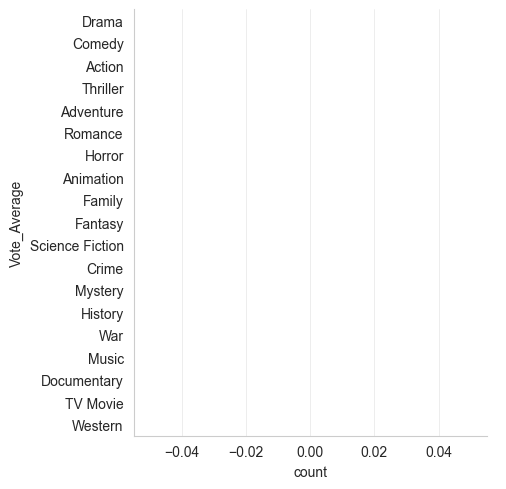

In [44]:
sns.catplot(y = "Vote_Average",data = df, kind = 'count',order = df['Genre'].value_counts().index,color='blue')
plt.show()

3)- What movie got the highest popularity? What's its genre?

In [45]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,Popular,Science Fiction


4)- What movie got the Lowest popularity? What's its genre?

In [111]:
df['Release_Date'].nunique()

102

In [94]:
df[df['Popularity']==df['Popularity'].min()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152.0,Popular,Music
25787,2021,The United States vs. Billie Holiday,13.354,152.0,Popular,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152.0,Popular,History
25789,1984,Threads,13.354,186.0,Popular,War
25790,1984,Threads,13.354,186.0,Popular,Drama
25791,1984,Threads,13.354,186.0,Popular,Science Fiction


5)- Which year has the most filmmed movies?

In [88]:
print(df.groupby('Release_Date')['Title'].nunique().idxmax())
df.groupby('Release_Date')['Title'].nunique().max()

2021


np.int64(713)

In [84]:
df.groupby(['Release_Date','Genre'])['Genre'].count().idxmax()

(np.int32(2021), 'Drama')

In [90]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [137]:
max = df["Release_Date"].value_counts().idxmax()
l=df["Release_Date"].value_counts().max()
print(max,l)

2021 1638


In [140]:
# Sort by count descending, then pick the first entry for each unique year
top_genre_per_year = df.groupby(['Release_Date', 'Genre'])['Genre'].count().reset_index(name='Count').sort_values('Count', ascending=False).drop_duplicates('Release_Date')
print(top_genre_per_year)
top_genre_per_year.shape


      Release_Date      Genre  Count
1358          2021      Drama    263
1282          2017      Drama    235
1301          2018      Drama    213
1263          2016      Drama    201
1320          2019      Drama    174
...            ...        ...    ...
0             1902  Adventure      1
30            1929     Horror      1
130           1944  Animation      1
16            1925    History      1
6             1920   Thriller      1

[102 rows x 3 columns]


(102, 3)